# Modelo de implementação DNN com TD-IDF e Dropout

In [ ]:
# =================================================================
# 1. CARREGAR DADOS E PREPARAÇÃO DOS LABELS
# =================================================================
import pandas as pd
import numpy as np
from collections import Counter
import sys
import os
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle
import gzip

sys.path.append(os.path.abspath("numpy_model"))
from numpy_model.neuralnet import NeuralNetwork
from numpy_model.layers import DenseLayer
from numpy_model.activation import ReLUActivation, SoftmaxActivation
from numpy_model.losses import CategoricalCrossEntropy
from numpy_model.metrics import accuracy
from numpy_model.data import Data

df = pd.read_csv('df_exportado.csv')

# Mapeamento para garantir a ordem dos pesos: [Human, OpenAI, Google, Meta, Anthropic]
label_map = {'Human': 0, 'OpenAI': 1, 'Google': 2, 'Meta': 3, 'Anthropic': 4}
y_indices = df['Label'].map(label_map).values

# Criar One-Hot Encoding
num_classes = 5
Y_treino = np.eye(num_classes)[y_indices]

In [2]:
# =================================================================
# 2. VETORIZAÇÃO TF-IDF MANUAL (AVANÇADO)
# =================================================================
print("A criar vocabulário TF-IDF...")
STOPWORDS = set(['the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were', 'to', 'of', 'in', 'with', 'as', 'for', 'on', 'at', 'by', 'it', 'this', 'that', 'from', 'which'])

todas_palavras = " ".join(df['Text']).lower().split()
todas_palavras = [palavra for palavra in todas_palavras if palavra not in STOPWORDS]

# Manter as top 5000 palavras
vocab = [palavra for palavra, count in Counter(todas_palavras).most_common(5000)]
word_to_idx = {palavra: i for i, palavra in enumerate(vocab)}

# --- CÁLCULO DO IDF (Inverse Document Frequency) ---
print("A calcular os pesos IDF (Isto pode demorar uns segundos)...")
df_counts = np.zeros(len(vocab))
for t in df['Text']:
    # Usar set() para contar em quantos documentos a palavra aparece
    palavras_unicas = set(str(t).lower().split())
    for palavra in palavras_unicas:
        if palavra in word_to_idx:
            df_counts[word_to_idx[palavra]] += 1

# Fórmula do IDF com smoothing para evitar divisão por zero
N = len(df['Text'])
idf = np.log((N + 1) / (df_counts + 1)) + 1

def vetorizar_tfidf(texto):
    vetor_tf = np.zeros(len(vocab))
    palavras = str(texto).lower().split()
    
    # Calcular Term Frequency (TF)
    for palavra in palavras:
        if palavra in word_to_idx:
            vetor_tf[word_to_idx[palavra]] += 1

    # Normalizar TF
    soma = np.sum(vetor_tf)
    if soma > 0:
        vetor_tf = vetor_tf / soma

    # Multiplicar TF pelo IDF
    return vetor_tf * idf

print("A converter textos em vetores TF-IDF (X_treino)...")
X_treino = np.array([vetorizar_tfidf(t) for t in df['Text']])
print("X_treino criado com shape:", X_treino.shape)

A criar vocabulário TF-IDF...
A calcular os pesos IDF (Isto pode demorar uns segundos)...
A converter textos em vetores TF-IDF (X_treino)...
X_treino criado com shape: (187072, 5000)


In [12]:
class DropoutLayer:
    def __init__(self, rate):
        self.rate = rate
        self.mask = None
        self.input_shape = None

    def set_input_shape(self, input_shape):
        self.input_shape = input_shape

    def output_shape(self):
        return self.input_shape

    def forward_propagation(self, inputs, training=True):
        if training:
            # Inverted Dropout
            self.mask = np.random.binomial(1, 1 - self.rate, size=inputs.shape) / (1 - self.rate)
            return inputs * self.mask
        return inputs

    def backward_propagation(self, dvalues):
        # Se a máscara não existir (ex: chamado fora do treino por erro), 
        # retorna os dvalues normais, mas idealmente dvalues * self.mask
        return dvalues * self.mask

In [5]:
# =================================================================
# 4. DIVISÃO DOS DADOS (TREINO E VALIDAÇÃO)
# =================================================================
pesos = [1.0, 1.0, 1.0, 1.0, 1.0]
tamanho_amostra_treino = min(50000, len(X_treino))

np.random.seed(42)
indices = np.random.permutation(tamanho_amostra_treino)
X_treino_shuf = X_treino[indices]
Y_treino_shuf = Y_treino[indices]

print("\nA separar 20% dos dados para validação...")
split_idx = int(tamanho_amostra_treino * 0.8)

X_train_final = X_treino_shuf[:split_idx]
Y_train_final = Y_treino_shuf[:split_idx]
X_val_final = X_treino_shuf[split_idx:]
Y_val_final = Y_treino_shuf[split_idx:]

print(f"Dados de Treino: {len(X_train_final)} textos")
print(f"Dados de Validação: {len(X_val_final)} textos")

dataset_treino_final = Data(X=X_train_final, y=Y_train_final)
dataset_val_final = Data(X=X_val_final, y=Y_val_final)


A separar 20% dos dados para validação...
Dados de Treino: 40000 textos
Dados de Validação: 10000 textos


In [6]:
# =================================================================
# 5. TREINO DO BASELINE (REGRESSÃO LOGÍSTICA)
# =================================================================
print("\n" + "="*40)
print("TREINO DO BASELINE: REGRESSÃO LOGÍSTICA (TF-IDF)")
print("="*40)

modelo_baseline = NeuralNetwork(
    epochs=50,
    batch_size=32, 
    learning_rate=0.01,
    loss=CategoricalCrossEntropy(class_weights=pesos), # type: ignore
    metric=accuracy, 
    verbose=True
)

modelo_baseline.add(DenseLayer(n_units=num_classes, input_shape=(X_train_final.shape[1],)))
modelo_baseline.add(SoftmaxActivation())

modelo_baseline.fit(dataset_treino_final)

prev_val_baseline = modelo_baseline.predict(dataset_val_final)
acc_baseline = np.mean(np.argmax(prev_val_baseline, axis=1) == np.argmax(Y_val_final, axis=1))
print(f"-> Acurácia do Baseline na Validação: {acc_baseline:.4f}")


TREINO DO BASELINE: REGRESSÃO LOGÍSTICA (TF-IDF)
Epoch 1/50 - loss: 1.5483 - accuracy: 0.2727
Epoch 2/50 - loss: 1.4704 - accuracy: 0.3530
Epoch 3/50 - loss: 1.4255 - accuracy: 0.3954
Epoch 4/50 - loss: 1.3858 - accuracy: 0.4285
Epoch 5/50 - loss: 1.3493 - accuracy: 0.4572
Epoch 6/50 - loss: 1.3155 - accuracy: 0.4854
Epoch 7/50 - loss: 1.2841 - accuracy: 0.5158
Epoch 8/50 - loss: 1.2551 - accuracy: 0.5383
Epoch 9/50 - loss: 1.2280 - accuracy: 0.5622
Epoch 10/50 - loss: 1.2027 - accuracy: 0.5808
Epoch 11/50 - loss: 1.1791 - accuracy: 0.5990
Epoch 12/50 - loss: 1.1569 - accuracy: 0.6154
Epoch 13/50 - loss: 1.1361 - accuracy: 0.6299
Epoch 14/50 - loss: 1.1165 - accuracy: 0.6431
Epoch 15/50 - loss: 1.0981 - accuracy: 0.6536
Epoch 16/50 - loss: 1.0807 - accuracy: 0.6641
Epoch 17/50 - loss: 1.0641 - accuracy: 0.6738
Epoch 18/50 - loss: 1.0485 - accuracy: 0.6809
Epoch 19/50 - loss: 1.0336 - accuracy: 0.6918
Epoch 20/50 - loss: 1.0195 - accuracy: 0.6960
Epoch 21/50 - loss: 1.0060 - accuracy: 

In [13]:
# =================================================================
# 6. TREINO DA DNN AVANÇADA (COM DROPOUT)
# =================================================================
print("\n" + "="*40)
print("TREINO DA DEEP NEURAL NETWORK AVANÇADA")
print("="*40)

modelo_final = NeuralNetwork(
    epochs=60, # Um pouco mais de épocas pois o Dropout atrasa a memorização
    batch_size=32, 
    learning_rate=0.01,
    loss=CategoricalCrossEntropy(class_weights=pesos), # type: ignore
    metric=accuracy, 
    verbose=True
)

# Arquitetura com Dropout para mitigar Overfitting
modelo_final.add(DenseLayer(n_units=128, input_shape=(X_train_final.shape[1],)))
modelo_final.add(ReLUActivation())
modelo_final.add(DropoutLayer(rate=0.3))

modelo_final.add(DenseLayer(n_units=64))
modelo_final.add(ReLUActivation())
modelo_final.add(DropoutLayer(rate=0.2))

modelo_final.add(DenseLayer(n_units=num_classes))
modelo_final.add(SoftmaxActivation())

modelo_final.fit(dataset_treino_final)


TREINO DA DEEP NEURAL NETWORK AVANÇADA
Epoch 1/60 - loss: 1.4836 - accuracy: 0.3934
Epoch 2/60 - loss: 1.2150 - accuracy: 0.5080
Epoch 3/60 - loss: 1.0876 - accuracy: 0.5591
Epoch 4/60 - loss: 1.0017 - accuracy: 0.5946
Epoch 5/60 - loss: 0.9373 - accuracy: 0.6208
Epoch 6/60 - loss: 0.8850 - accuracy: 0.6413
Epoch 7/60 - loss: 0.8468 - accuracy: 0.6560
Epoch 8/60 - loss: 0.8101 - accuracy: 0.6685
Epoch 9/60 - loss: 0.7804 - accuracy: 0.6806
Epoch 10/60 - loss: 0.7547 - accuracy: 0.6903
Epoch 11/60 - loss: 0.7299 - accuracy: 0.6976
Epoch 12/60 - loss: 0.7058 - accuracy: 0.7045
Epoch 13/60 - loss: 0.6906 - accuracy: 0.7116
Epoch 14/60 - loss: 0.6744 - accuracy: 0.7177
Epoch 15/60 - loss: 0.6553 - accuracy: 0.7202
Epoch 16/60 - loss: 0.6446 - accuracy: 0.7293
Epoch 17/60 - loss: 0.6325 - accuracy: 0.7321
Epoch 18/60 - loss: 0.6204 - accuracy: 0.7386
Epoch 19/60 - loss: 0.6065 - accuracy: 0.7437
Epoch 20/60 - loss: 0.5966 - accuracy: 0.7458
Epoch 21/60 - loss: 0.5870 - accuracy: 0.7515
Epo

In [15]:
# =================================================================
# 7. AVALIAÇÃO FINAL E OVERFITTING
# =================================================================
print("\n" + "="*40)
print("ANÁLISE DE OVERFITTING")
print("="*40)

prev_treino = modelo_final.predict(dataset_treino_final)
acc_treino = np.mean(np.argmax(prev_treino, axis=1) == np.argmax(Y_train_final, axis=1))

prev_val = modelo_final.predict(dataset_val_final)
acc_val = np.mean(np.argmax(prev_val, axis=1) == np.argmax(Y_val_final, axis=1))

print(f"Acurácia no Treino (Dados vistos)      : {acc_treino:.4f}")
print(f"Acurácia na Validação (Dados invisíveis): {acc_val:.4f}")

diferenca = acc_treino - acc_val
print(f"Diferença (Queda de performance)        : {diferenca:.4f}")

if diferenca > 0.05:
    print("\nCUIDADO: O modelo apresenta sinais de Overfitting.")
else:
    print("\nEXCELENTE: O modelo está saudável e generalizou bem!")


ANÁLISE DE OVERFITTING
Acurácia no Treino (Dados vistos)      : 0.9075
Acurácia na Validação (Dados invisíveis): 0.8867
Diferença (Queda de performance)        : 0.0208

EXCELENTE: O modelo está saudável e generalizou bem!


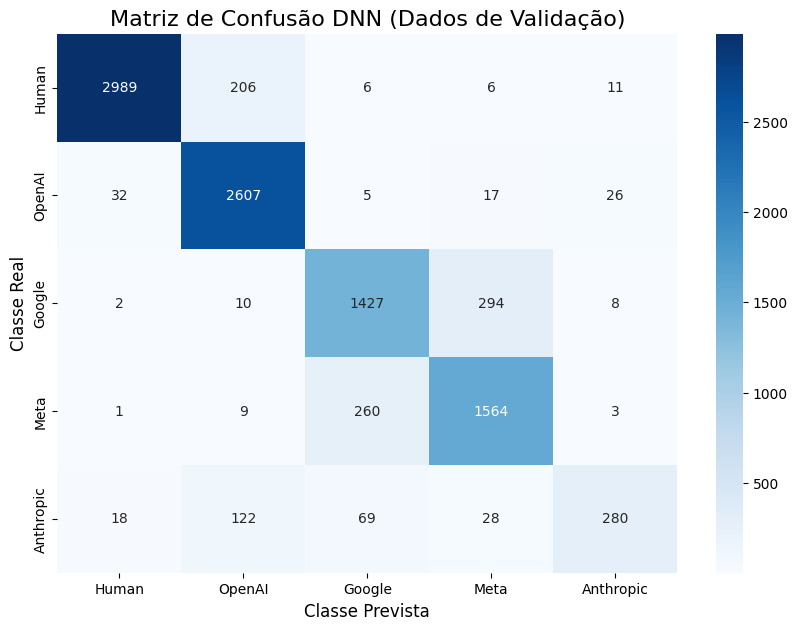

Modelo e TF-IDF guardados com sucesso para a submissão!


In [16]:
# =================================================================
# 8. MATRIZ DE CONFUSÃO E EXPORTAÇÃO
# =================================================================
classes_previstas_val = np.argmax(prev_val, axis=1)
classes_reais_val = np.argmax(Y_val_final, axis=1)

nomes_classes = ['Human', 'OpenAI', 'Google', 'Meta', 'Anthropic']
cm = confusion_matrix(classes_reais_val, classes_previstas_val)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, 
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão DNN (Dados de Validação)', fontsize=16)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.show()

# Guardar o TF-IDF (vocab e idf) e o modelo
with open('tfidf_numpy.pkl', 'wb') as f:
    pickle.dump({'vocab': vocab, 'idf': idf}, f)

with gzip.open('modelo_numpy_final.pkl.gz', 'wb') as f:
    pickle.dump(modelo_final, f)

print("Modelo e TF-IDF guardados com sucesso para a submissão!")